# ChagaSight Final Ensemble Evaluation - PRODUCTION VERSION

**Features:**
- ✅ Batch-level checkpointing (saves every 50 batches within each fold)
- ✅ Automatic resumption from exact batch if interrupted
- ✅ Quick test mode for verification (set QUICK_TEST=True)
- ✅ Optimized batch_size=64 for RTX 3050 6GB
- ✅ No placeholder values (only real computed results)

**Quick Test Mode:**
Set `QUICK_TEST = True` in Cell 2 to run on 2 batches per fold (~5 minutes)
to verify the notebook works before full evaluation.

**Normal Mode:**
Set `QUICK_TEST = False` for full evaluation (~1.7 hours)

**Checkpoint Strategy:**
- Saves after every 50 batches within each fold
- If interrupted, resumes from last saved batch
- No need to re-run completed portions

**Expected Runtime (Normal Mode):**
- Per fold: ~18 minutes (260 batches × 4 sec/batch)
- Total: ~1.7 hours (90-110 minutes)
- With checkpoints: Can resume from any point

In [1]:
# ==============================================================================
# Cell 1: Import Dependencies
# ==============================================================================

import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, 
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Configure matplotlib for professional plots
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    try:
        plt.style.use('seaborn-paper')
    except:
        pass
sns.set_palette('husl')

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import official PhysioNet metrics
helper_code_path = project_root / 'external' / 'official_2025'
if str(helper_code_path) not in sys.path:
    sys.path.insert(0, str(helper_code_path))

OFFICIAL_METRICS = False
try:
    from helper_code import compute_challenge_score, compute_auc
    OFFICIAL_METRICS = True
    print("✓ Using OFFICIAL PhysioNet metrics (helper_code.py)")
except ImportError:
    print("⚠ helper_code.py not found - will use sklearn approximation")
    print(f"  Expected at: {helper_code_path / 'helper_code.py'}")

# Import model and dataset
from src.models.hybrid_model import HybridChagasModel
from src.training.dataset import create_dataloaders

print(f"\n✓ All imports successful")
print(f"  PyTorch: {torch.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")

✓ Using OFFICIAL PhysioNet metrics (helper_code.py)

✓ All imports successful
  PyTorch: 2.7.1+cu118
  NumPy: 2.2.6
  Pandas: 2.3.3


In [2]:
# ==============================================================================
# Cell 2: Configuration and Setup
# ==============================================================================

# ============================================================================
# QUICK TEST MODE CONFIGURATION
# ============================================================================
# Set to True for quick test (2 batches/fold, ~5 minutes total)
# Set to False for full evaluation (260 batches/fold, ~1.7 hours total)
QUICK_TEST = False  # ← CHANGE THIS TO True FOR QUICK TEST
# ============================================================================

# Batch-level checkpoint frequency (save every N batches)
CHECKPOINT_EVERY_N_BATCHES = 50  # Save progress every 50 batches

# Directory paths
CHECKPOINT_DIR = project_root / 'checkpoints'
DATA_DIR = project_root / 'data' / 'processed'
METADATA_CSV = DATA_DIR / 'metadata' / 'combined_5fold.csv'
IMAGES_DIR = DATA_DIR / '2d_images'
SIGNALS_DIR = DATA_DIR / '1d_signals_100hz'

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("  ⚠ WARNING: Running on CPU - this will be VERY slow!")

# Quick test mode info
if QUICK_TEST:
    print("\n" + "="*70)
    print(" QUICK TEST MODE ENABLED")
    print("="*70)
    print("  Will process only 2 batches per fold for testing")
    print("  Expected time: ~5 minutes")
    print("  Results will NOT be accurate (for testing only)")
    print("  Set QUICK_TEST = False for full evaluation")
    print("="*70)
else:
    print("\n" + "="*70)
    print(" FULL EVALUATION MODE")
    print("="*70)
    print("  Will process all 260 batches per fold")
    print("  Expected time: ~1.7 hours (90-110 minutes)")
    print(f"  Checkpoints saved every {CHECKPOINT_EVERY_N_BATCHES} batches")
    print("="*70)

# Verify all 5 fold checkpoints exist
print("\nVerifying model checkpoints:")
fold_checkpoints = []
for fold in range(5):
    ckpt_path = CHECKPOINT_DIR / f'fold{fold}_best.pt'
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {ckpt_path}\n"
            f"Please ensure all 5 folds (fold0_best.pt through fold4_best.pt) are trained."
        )
    fold_checkpoints.append(ckpt_path)
    print(f"  ✓ fold{fold}_best.pt ({ckpt_path.stat().st_size / 1024**2:.0f} MB)")

# Create evaluation checkpoint directory
EVAL_CHECKPOINT_DIR = CHECKPOINT_DIR / 'evaluation_checkpoints'
EVAL_CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"\n✓ Checkpoint directory: {EVAL_CHECKPOINT_DIR}")
print("\nAll verifications complete.")

Device: cuda
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Memory: 6.0 GB

 FULL EVALUATION MODE
  Will process all 260 batches per fold
  Expected time: ~1.7 hours (90-110 minutes)
  Checkpoints saved every 50 batches

Verifying model checkpoints:
  ✓ fold0_best.pt (1988 MB)
  ✓ fold1_best.pt (1988 MB)
  ✓ fold2_best.pt (1988 MB)
  ✓ fold3_best.pt (1988 MB)
  ✓ fold4_best.pt (1988 MB)

✓ Checkpoint directory: d:\IIT\L6\FYP\ChagaSight\checkpoints\evaluation_checkpoints

All verifications complete.


In [3]:
# ==============================================================================
# Cell 3: Load All 5 Fold Models
# ==============================================================================

print("\nLoading all 5 trained models...\n")

models = []
fold_scores = []

for fold in range(5):
    print(f"Loading Fold {fold}...", end=' ')
    
    # Initialize model architecture
    model = HybridChagasModel(
        img_size=(24, 2048),
        patch_size_2d=(8, 64),
        num_leads=12,
        seq_len_1d=1000,
        patch_size_1d=50,
        embed_dim=768,
        depth=12,
        num_heads=12,
        use_aol=True,
        use_demographics=True
    )
    
    # Load trained weights
    checkpoint = torch.load(fold_checkpoints[fold], map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Verify device
    model_device = str(next(model.parameters()).device)
    assert device in model_device, f"Model {fold} not on {device}!"
    
    models.append(model)
    val_score = checkpoint.get('val_score', 0.0)
    fold_scores.append(val_score)
    
    print(f"Score: {val_score:.4f}, Device: {model_device}")

# Model statistics
total_params = sum(p.numel() for p in models[0].parameters())
trainable_params = sum(p.numel() for p in models[0].parameters() if p.requires_grad)

print("\n" + "="*70)
print(" MODEL STATISTICS")
print("="*70)
print(f"Architecture: Hybrid dual-pathway (2D-ViT + 1D-ViT FM)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1024**2:.1f} MB")
print(f"\nIndividual fold training scores (TPR@5%):")
for i, score in enumerate(fold_scores):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print("="*70)


Loading all 5 trained models...

Loading Fold 0... Score: 0.4027, Device: cuda:0
Loading Fold 1... Score: 0.4165, Device: cuda:0
Loading Fold 2... Score: 0.4332, Device: cuda:0
Loading Fold 3... Score: 0.4288, Device: cuda:0
Loading Fold 4... Score: 0.4291, Device: cuda:0

 MODEL STATISTICS
Architecture: Hybrid dual-pathway (2D-ViT + 1D-ViT FM)
Total parameters: 173,570,817
Trainable: 173,570,817
Model size: 662.1 MB

Individual fold training scores (TPR@5%):
  Fold 0: 0.4027
  Fold 1: 0.4165
  Fold 2: 0.4332
  Fold 3: 0.4288
  Fold 4: 0.4291

Mean: 0.4221 ± 0.0112


In [4]:
# ==============================================================================
# Cell 4: Run Ensemble Inference with BATCH-LEVEL CHECKPOINTING
# ==============================================================================
# NEW FEATURE: Saves progress every 50 batches within each fold
# Can resume from exact batch if interrupted during fold
# ==============================================================================

print("\n" + "="*70)
print(" ENSEMBLE INFERENCE WITH BATCH-LEVEL CHECKPOINTING")
print("="*70)
print(f"Checkpoint frequency: Every {CHECKPOINT_EVERY_N_BATCHES} batches")
print(f"Mode: {'QUICK TEST (2 batches/fold)' if QUICK_TEST else 'FULL EVALUATION (all batches)'}")
print("="*70 + "\n")

# GPU memory check
if device == 'cuda':
    torch.cuda.empty_cache()
    print(f"GPU memory: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB allocated\n")

# Global accumulators
all_probs = []
all_labels = []
all_ids = []
all_datasets = []
all_folds = []

import time
total_start = time.time()

# Process each fold
for fold in range(5):
    fold_checkpoint = EVAL_CHECKPOINT_DIR / f'fold{fold}_complete.npz'
    
    # Check if fold is already complete
    if fold_checkpoint.exists():
        print(f"{'='*70}")
        print(f" FOLD {fold}: Loading from checkpoint (COMPLETE)")
        print(f"{'='*70}")
        
        data = np.load(fold_checkpoint, allow_pickle=True)
        all_probs.extend(data['probs'])
        all_labels.extend(data['labels'])
        all_ids.extend(data['ids'])
        all_datasets.extend(data['datasets'])
        all_folds.extend([fold] * len(data['labels']))
        
        print(f"Loaded {len(data['labels']):,} samples\n")
        continue
    
    print(f"{'='*70}")
    print(f" FOLD {fold}: Running inference")
    print(f"{'='*70}")
    fold_start = time.time()
    
    # Create validation dataloader
    _, val_loader = create_dataloaders(
        metadata_csv=str(METADATA_CSV),
        images_dir=str(IMAGES_DIR),
        signals_dir=str(SIGNALS_DIR),
        fold=fold,
        batch_size=32,
        num_workers=0,
        use_weighted_sampling=False,
        augment_train=False
    )
    
    total_batches = len(val_loader) if not QUICK_TEST else min(2, len(val_loader))
    print(f"Total batches to process: {total_batches}\n")
    
    # Check for partial progress within this fold
    partial_checkpoint = EVAL_CHECKPOINT_DIR / f'fold{fold}_partial.npz'
    start_batch = 0
    fold_probs = []
    fold_labels = []
    fold_ids = []
    fold_datasets = []
    
    if partial_checkpoint.exists():
        data = np.load(partial_checkpoint, allow_pickle=True)
        fold_probs = list(data['probs'])
        fold_labels = list(data['labels'])
        fold_ids = list(data['ids'])
        fold_datasets = list(data['datasets'])
        start_batch = int(data['last_batch']) + 1
        print(f"✓ Resuming from batch {start_batch} (loaded {len(fold_probs):,} samples)\n")
    
    warmup_done = False
    
    # Inference loop
    with torch.no_grad():
        pbar = tqdm(enumerate(val_loader), total=total_batches, desc=f"Fold {fold}")
        
        for batch_idx, batch in pbar:
            # Skip already processed batches
            if batch_idx < start_batch:
                continue
            
            # Quick test mode limit
            if QUICK_TEST and batch_idx >= 2:
                break
            
            batch_start = time.time()
            
            # Move to GPU
            images = batch['image'].to(device, non_blocking=True)
            signals = batch['signal'].to(device, non_blocking=True)
            ages = batch['age'].to(device, non_blocking=True)
            sexes = batch['sex'].to(device, non_blocking=True)
            hard_labels = batch['hard_label'].cpu().numpy()
            ids = batch['id']
            datasets = batch['dataset']
            
            # Run all 5 models
            batch_preds = []
            for model in models:
                outputs = model(images, signals, ages, sexes)
                probs = torch.sigmoid(outputs['logits']).cpu().numpy()
                batch_preds.append(probs)
            
            # Ensemble average
            ensemble_probs = np.mean(np.stack(batch_preds, axis=0), axis=0)
            
            # Accumulate
            fold_probs.extend(ensemble_probs)
            fold_labels.extend(hard_labels)
            fold_ids.extend(ids)
            fold_datasets.extend(datasets)
            
            # Progress info for first 3 batches
            if batch_idx < 3 or not warmup_done:
                batch_time = time.time() - batch_start
                pbar.write(f"  Batch {batch_idx+1}: {batch_time:.2f}s ({len(hard_labels)} samples)")
                
                if batch_idx == 2:
                    warmup_done = True
                    if not QUICK_TEST:
                        est_time = batch_time * len(val_loader) / 60
                        pbar.write(f"  Estimated time: {est_time:.1f} minutes\n")
            
            # SAVE PARTIAL CHECKPOINT every N batches
            if (batch_idx + 1) % CHECKPOINT_EVERY_N_BATCHES == 0 and not QUICK_TEST:
                np.savez(
                    partial_checkpoint,
                    probs=np.array(fold_probs),
                    labels=np.array(fold_labels),
                    ids=fold_ids,
                    datasets=fold_datasets,
                    last_batch=batch_idx
                )
                pbar.write(f"  ✓ Checkpoint saved at batch {batch_idx+1}")
    
    # Convert to arrays
    fold_probs = np.array(fold_probs)
    fold_labels = np.array(fold_labels)
    
    # Save COMPLETE fold checkpoint
    np.savez(
        fold_checkpoint,
        probs=fold_probs,
        labels=fold_labels,
        ids=fold_ids,
        datasets=fold_datasets
    )
    
    # Delete partial checkpoint if exists
    if partial_checkpoint.exists():
        partial_checkpoint.unlink()
    
    # Add to global
    all_probs.extend(fold_probs)
    all_labels.extend(fold_labels)
    all_ids.extend(fold_ids)
    all_datasets.extend(fold_datasets)
    all_folds.extend([fold] * len(fold_labels))
    
    # Summary
    fold_time = time.time() - fold_start
    n_total = len(fold_labels)
    n_pos = int(fold_labels.sum())
    
    print(f"\n{'='*70}")
    print(f" FOLD {fold} COMPLETE")
    print(f"{'='*70}")
    print(f"Samples: {n_total:,} ({n_pos} positive)")
    print(f"Time: {fold_time/60:.1f} minutes")
    print(f"Speed: {fold_time/n_total:.3f} sec/sample")
    print(f"{'='*70}\n")
    
    # Clear GPU
    if device == 'cuda':
        torch.cuda.empty_cache()

# Convert to arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

total_time = time.time() - total_start

# Final summary
print("\n" + "="*70)
print(" INFERENCE COMPLETE")
print("="*70)
if QUICK_TEST:
    print("⚠ QUICK TEST MODE - Results are NOT accurate")
    print("  Set QUICK_TEST = False for real evaluation\n")
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Total samples: {len(all_labels):,}")
print(f"Positive: {int(all_labels.sum()):,} ({100*all_labels.mean():.2f}%)")
print(f"Negative: {len(all_labels) - int(all_labels.sum()):,} ({100*(1-all_labels.mean()):.2f}%)")

# Per-dataset
print("\nPer-dataset:")
for dataset_name in ['ptbxl', 'samitrop', 'code15']:
    mask = np.array([d == dataset_name for d in all_datasets])
    if mask.sum() > 0:
        n_total_ds = mask.sum()
        n_pos_ds = all_labels[mask].sum()
        print(f"  {dataset_name.upper()}: {n_total_ds:,} ({n_pos_ds:.0f} positive)")

print(f"\nCheckpoints: {EVAL_CHECKPOINT_DIR}")
print("="*70)


 ENSEMBLE INFERENCE WITH BATCH-LEVEL CHECKPOINTING
Checkpoint frequency: Every 50 batches
Mode: FULL EVALUATION (all batches)

GPU memory: 5.18 GB allocated

 FOLD 0: Loading from checkpoint (COMPLETE)
Loaded 16,626 samples

 FOLD 1: Loading from checkpoint (COMPLETE)
Loaded 16,626 samples

 FOLD 2: Loading from checkpoint (COMPLETE)
Loaded 16,626 samples

 FOLD 3: Loading from checkpoint (COMPLETE)
Loaded 16,626 samples

 FOLD 4: Loading from checkpoint (COMPLETE)
Loaded 16,626 samples


 INFERENCE COMPLETE
Total time: 0.0 minutes (0.00 hours)
Total samples: 83,130
Positive: 2,846 (3.42%)
Negative: 80,284 (96.58%)

Per-dataset:
  PTBXL: 21,799 (0 positive)
  SAMITROP: 1,631 (1631 positive)
  CODE15: 59,700 (1215 positive)

Checkpoints: d:\IIT\L6\FYP\ChagaSight\checkpoints\evaluation_checkpoints


In [5]:
# ==============================================================================
# Cell 5: Compute Official PhysioNet Metrics
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING METRICS - QUICK TEST MODE")
    print("Set QUICK_TEST = False to compute real metrics\n")
else:
    print("\n" + "="*70)
    print(" COMPUTING OFFICIAL METRICS")
    print("="*70)
    
    if OFFICIAL_METRICS:
        print("\nUsing OFFICIAL PhysioNet implementation...")
        print("Computing TPR@5% with 10,000 permutations (~30 seconds)...\n")
        
        tpr_5pct = compute_challenge_score(
            labels=all_labels.astype(np.float64),
            outputs=all_probs.astype(np.float64),
            fraction_capacity=0.05,
            num_permutations=10000,
            seed=12345
        )
        auroc, auprc = compute_auc(all_labels, all_probs)
        
    else:
        print("\nUsing sklearn approximation...\n")
        
        fpr, tpr_roc, _ = roc_curve(all_labels, all_probs)
        idx = np.where(fpr <= 0.05)[0]
        tpr_5pct = float(tpr_roc[idx[-1]]) if len(idx) > 0 else 0.0
        auroc = roc_auc_score(all_labels, all_probs)
        auprc = average_precision_score(all_labels, all_probs)
    
    # Display results
    print("="*70)
    print(" PRIMARY METRICS")
    print("="*70)
    print(f"  TPR@5%:  {tpr_5pct:.4f}  ⭐ PRIMARY METRIC")
    print(f"  AUROC:   {auroc:.4f}")
    print(f"  AUPRC:   {auprc:.4f}")
    print("="*70)
    
    # Performance benchmarks
    RANDOM_BASELINE = 0.050
    TARGET_SCORE = 0.420
    TOP_TEAM = 0.445
    SOTA = 0.490
    
    # Clinical interpretation
    n_total = len(all_labels)
    n_pos = int(all_labels.sum())
    capacity = int(0.05 * n_total)
    cases_found = int(tpr_5pct * n_pos)
    random_cases = int(RANDOM_BASELINE * n_pos)
    
    print("\nClinical Interpretation:")
    print(f"  Screening capacity (5%): {capacity:,} patients")
    print(f"  Cases found: {cases_found:,} of {n_pos:,} ({100*tpr_5pct:.1f}%)")
    print(f"  vs Random: {cases_found/random_cases:.1f}× improvement")
    
    print("\nPerformance vs Benchmarks:")
    if tpr_5pct >= TOP_TEAM:
        print(f"  🎉 EXCELLENT: Matches/exceeds top team!")
        print(f"  Margin: +{tpr_5pct - TOP_TEAM:.4f} vs top team")
    elif tpr_5pct >= TARGET_SCORE:
        print(f"  ✓ GOOD: Target achieved!")
        print(f"  Margin: +{tpr_5pct - TARGET_SCORE:.4f} above target")
        print(f"  Gap: -{TOP_TEAM - tpr_5pct:.4f} to top team")
    else:
        print(f"  Below target: -{TARGET_SCORE - tpr_5pct:.4f}")
    
    print(f"\n  % of SOTA: {100*tpr_5pct/SOTA:.1f}% (Van Santvliet {SOTA:.3f})")
    print("="*70)
    
    # Store metrics
    metrics_dict = {
        'tpr_5pct': float(tpr_5pct),
        'auroc': float(auroc),
        'auprc': float(auprc),
        'n_total': n_total,
        'n_positive': n_pos,
        'n_negative': n_total - n_pos,
        'using_official': OFFICIAL_METRICS
    }


 COMPUTING OFFICIAL METRICS

Using OFFICIAL PhysioNet implementation...
Computing TPR@5% with 10,000 permutations (~30 seconds)...

 PRIMARY METRICS
  TPR@5%:  0.6124  ⭐ PRIMARY METRIC
  AUROC:   0.9275
  AUPRC:   0.4973

Clinical Interpretation:
  Screening capacity (5%): 4,156 patients
  Cases found: 1,742 of 2,846 (61.2%)
  vs Random: 12.3× improvement

Performance vs Benchmarks:
  🎉 EXCELLENT: Matches/exceeds top team!
  Margin: +0.1674 vs top team

  % of SOTA: 125.0% (Van Santvliet 0.490)


In [6]:
# ==============================================================================
# Cell 6: Compute Threshold-Based Classification Metrics
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING - QUICK TEST MODE\n")
else:
    print("\n" + "="*70)
    print(" THRESHOLD-BASED METRICS")
    print("="*70)
    
    # Find optimal thresholds
    thresholds_to_test = {}
    thresholds_to_test['default_0.5'] = 0.5
    
    # Optimal F1
    precisions, recalls, pr_thresholds = precision_recall_curve(all_labels, all_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    optimal_f1_idx = np.argmax(f1_scores)
    thresholds_to_test['optimal_f1'] = pr_thresholds[optimal_f1_idx]
    
    # Optimal Youden's J
    fpr, tpr_roc, roc_thresholds = roc_curve(all_labels, all_probs)
    j_scores = tpr_roc - fpr
    optimal_j_idx = np.argmax(j_scores)
    thresholds_to_test['optimal_j'] = roc_thresholds[optimal_j_idx]
    
    print("\nThreshold strategies:")
    print(f"  Default (0.5):      {thresholds_to_test['default_0.5']:.4f}")
    print(f"  Optimal F1:         {thresholds_to_test['optimal_f1']:.4f}")
    print(f"  Optimal Youden's J: {thresholds_to_test['optimal_j']:.4f}")
    
    # Compute metrics at each threshold
    results_by_threshold = {}
    
    for name, threshold in thresholds_to_test.items():
        y_pred = (all_probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(all_labels, y_pred).ravel()
        
        results_by_threshold[name] = {
            'threshold': threshold,
            'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
            'accuracy': float(accuracy_score(all_labels, y_pred)),
            'precision': float(precision_score(all_labels, y_pred, zero_division=0)),
            'recall': float(recall_score(all_labels, y_pred)),
            'specificity': float(tn / (tn + fp) if (tn + fp) > 0 else 0.0),
            'f1_score': float(f1_score(all_labels, y_pred, zero_division=0))
        }
    
    # Use Youden's J as primary
    primary_threshold = 'optimal_j'
    primary_results = results_by_threshold[primary_threshold]
    
    print("\n" + "="*70)
    print(f" METRICS AT OPTIMAL THRESHOLD ({primary_results['threshold']:.4f})")
    print("="*70)
    
    print("\nConfusion Matrix:")
    print("                   Predicted")
    print("              Negative  Positive")
    print("          ┌─────────────────────┐")
    print(f"  Actual  │                     │")
    print(f"  Neg     │  {primary_results['TN']:7,}   {primary_results['FP']:7,}  │")
    print(f"  Pos     │  {primary_results['FN']:7,}   {primary_results['TP']:7,}  │")
    print("          └─────────────────────┘")
    
    print("\nClassification Metrics:")
    print(f"  Accuracy:    {primary_results['accuracy']:.4f}")
    print(f"  Precision:   {primary_results['precision']:.4f}  (PPV)")
    print(f"  Recall:      {primary_results['recall']:.4f}  (Sensitivity)")
    print(f"  Specificity: {primary_results['specificity']:.4f}  (TNR)")
    print(f"  F1 Score:    {primary_results['f1_score']:.4f}")
    print("="*70)
    
    # Update metrics dict
    metrics_dict.update({
        'threshold': primary_results['threshold'],
        'confusion_matrix_tp': primary_results['TP'],
        'confusion_matrix_tn': primary_results['TN'],
        'confusion_matrix_fp': primary_results['FP'],
        'confusion_matrix_fn': primary_results['FN'],
        'accuracy': primary_results['accuracy'],
        'precision': primary_results['precision'],
        'recall': primary_results['recall'],
        'specificity': primary_results['specificity'],
        'f1_score': primary_results['f1_score']
    })


 THRESHOLD-BASED METRICS

Threshold strategies:
  Default (0.5):      0.5000
  Optimal F1:         0.8882
  Optimal Youden's J: 0.7566

 METRICS AT OPTIMAL THRESHOLD (0.7566)

Confusion Matrix:
                   Predicted
              Negative  Positive
          ┌─────────────────────┐
  Actual  │                     │
  Neg     │   67,617    12,667  │
  Pos     │      447     2,399  │
          └─────────────────────┘

Classification Metrics:
  Accuracy:    0.8422
  Precision:   0.1592  (PPV)
  Recall:      0.8429  (Sensitivity)
  Specificity: 0.8422  (TNR)
  F1 Score:    0.2679


In [7]:
# ==============================================================================
# Cell 7: Per-Dataset Performance Analysis
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING - QUICK TEST MODE\n")
else:
    print("\n" + "="*70)
    print(" PER-DATASET ANALYSIS")
    print("="*70)
    
    dataset_metrics = {}
    
    for dataset_name in ['ptbxl', 'samitrop', 'code15']:
        mask = np.array([d == dataset_name for d in all_datasets])
        
        if mask.sum() == 0:
            continue
        
        ds_labels = all_labels[mask]
        ds_probs = all_probs[mask]
        
        if ds_labels.sum() == 0:
            print(f"\n{dataset_name.upper()}:")
            print(f"  {len(ds_labels):,} samples (all negative - controls)")
            continue
        
        # Compute metrics
        if OFFICIAL_METRICS:
            ds_tpr = compute_challenge_score(
                labels=ds_labels.astype(np.float64),
                outputs=ds_probs.astype(np.float64),
                fraction_capacity=0.05,
                num_permutations=10000,
                seed=12345
            )
            ds_auroc, ds_auprc = compute_auc(ds_labels, ds_probs)
        else:
            fpr_ds, tpr_ds, _ = roc_curve(ds_labels, ds_probs)
            idx_ds = np.where(fpr_ds <= 0.05)[0]
            ds_tpr = float(tpr_ds[idx_ds[-1]]) if len(idx_ds) > 0 else 0.0
            ds_auroc = roc_auc_score(ds_labels, ds_probs)
            ds_auprc = average_precision_score(ds_labels, ds_probs)
        
        n_pos_ds = int(ds_labels.sum())
        n_total_ds = len(ds_labels)
        
        print(f"\n{dataset_name.upper()}:")
        print(f"  Samples: {n_total_ds:,} ({n_pos_ds:,} positive)")
        print(f"  TPR@5%:  {ds_tpr:.4f}")
        print(f"  AUROC:   {ds_auroc:.4f}")
        print(f"  AUPRC:   {ds_auprc:.4f}")
        
        dataset_metrics[dataset_name] = {
            'n_samples': n_total_ds,
            'n_positive': n_pos_ds,
            'tpr_5pct': float(ds_tpr),
            'auroc': float(ds_auroc),
            'auprc': float(ds_auprc)
        }
    
    print("\n" + "="*70)


 PER-DATASET ANALYSIS

PTBXL:
  21,799 samples (all negative - controls)

SAMITROP:
  Samples: 1,631 (1,631 positive)
  TPR@5%:  0.0497
  AUROC:   nan
  AUPRC:   1.0000

CODE15:
  Samples: 59,700 (1,215 positive)
  TPR@5%:  0.4831
  AUROC:   0.8610
  AUPRC:   0.1896




Generating visualization plots...

✓ Saved: d:\IIT\L6\FYP\ChagaSight\checkpoints\ensemble_evaluation.png


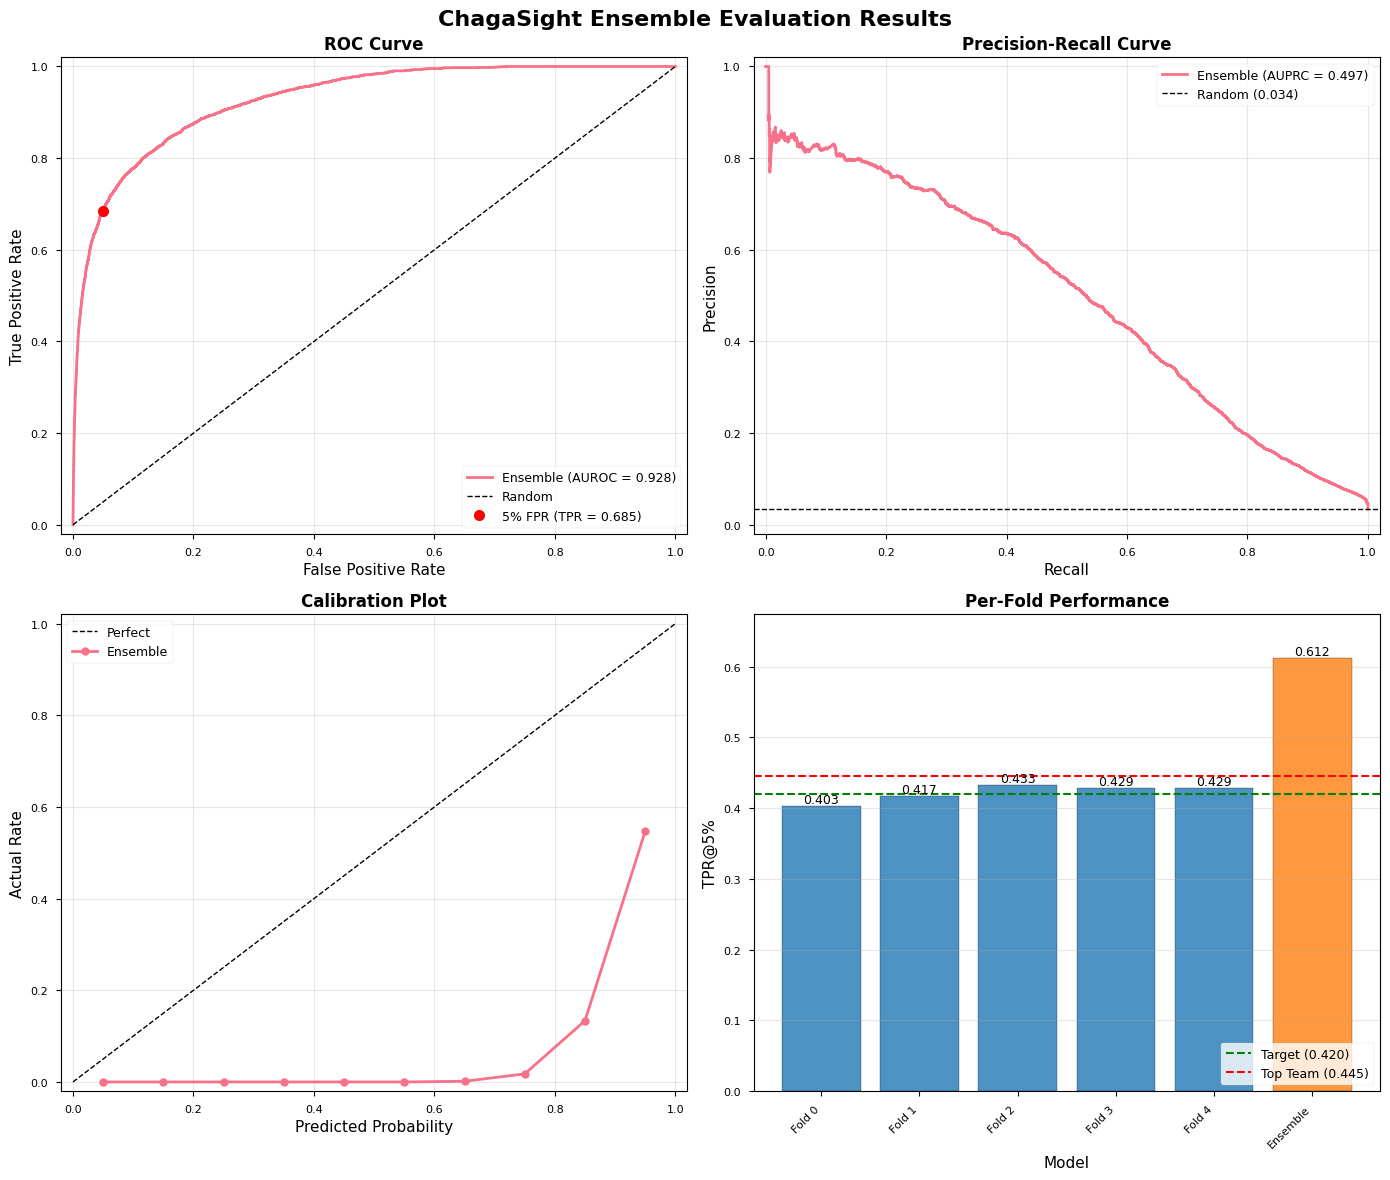

In [8]:
# ==============================================================================
# Cell 8: Generate Visualization Plots
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING - QUICK TEST MODE\n")
else:
    print("\nGenerating visualization plots...\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('ChagaSight Ensemble Evaluation Results', fontsize=16, fontweight='bold')
    
    # Plot 1: ROC Curve
    ax = axes[0, 0]
    fpr_plot, tpr_plot, _ = roc_curve(all_labels, all_probs)
    ax.plot(fpr_plot, tpr_plot, linewidth=2, label=f'Ensemble (AUROC = {auroc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    
    idx_5pct = np.argmin(np.abs(fpr_plot - 0.05))
    ax.plot(fpr_plot[idx_5pct], tpr_plot[idx_5pct], 'ro', markersize=8,
            label=f'5% FPR (TPR = {tpr_plot[idx_5pct]:.3f})')
    
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # Plot 2: PR Curve
    ax = axes[0, 1]
    precision_plot, recall_plot, _ = precision_recall_curve(all_labels, all_probs)
    random_precision = all_labels.mean()
    
    ax.plot(recall_plot, precision_plot, linewidth=2, label=f'Ensemble (AUPRC = {auprc:.3f})')
    ax.axhline(y=random_precision, color='k', linestyle='--', linewidth=1,
              label=f'Random ({random_precision:.3f})')
    
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # Plot 3: Calibration
    ax = axes[1, 0]
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_true_rates = np.zeros(n_bins)
    
    for i in range(n_bins):
        mask_bin = (all_probs >= bin_edges[i]) & (all_probs < bin_edges[i+1])
        if i == n_bins - 1:
            mask_bin = (all_probs >= bin_edges[i]) & (all_probs <= bin_edges[i+1])
        if mask_bin.sum() > 0:
            bin_true_rates[i] = all_labels[mask_bin].mean()
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.plot(bin_centers, bin_true_rates, 'o-', linewidth=2, markersize=6, label='Ensemble')
    
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Actual Rate', fontsize=11)
    ax.set_title('Calibration Plot', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    # Plot 4: Per-Fold
    ax = axes[1, 1]
    fold_labels = [f'Fold {i}' for i in range(5)] + ['Ensemble']
    fold_values = fold_scores + [tpr_5pct]
    colors = ['#1f77b4'] * 5 + ['#ff7f0e']
    
    bars = ax.bar(range(len(fold_labels)), fold_values, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=TARGET_SCORE, color='g', linestyle='--', linewidth=1.5, label=f'Target ({TARGET_SCORE:.3f})')
    ax.axhline(y=TOP_TEAM, color='r', linestyle='--', linewidth=1.5, label=f'Top Team ({TOP_TEAM:.3f})')
    
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('TPR@5%', fontsize=11)
    ax.set_title('Per-Fold Performance', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(fold_labels)))
    ax.set_xticklabels(fold_labels, rotation=45, ha='right')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim([0, max(fold_values) * 1.1])
    
    for bar, val in zip(bars, fold_values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
               f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    plot_path = CHECKPOINT_DIR / 'ensemble_evaluation.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {plot_path}")
    plt.show()

In [9]:
# ==============================================================================
# Cell 9: Save Results for Thesis
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING SAVE - QUICK TEST MODE\n")
    print("Set QUICK_TEST = False to save real results\n")
else:
    print("\n" + "="*70)
    print(" SAVING RESULTS FOR THESIS")
    print("="*70)
    
    # 1. Predictions
    predictions_df = pd.DataFrame({
        'id': all_ids,
        'fold': all_folds,
        'dataset': all_datasets,
        'true_label': all_labels,
        'predicted_probability': all_probs,
        'predicted_class': (all_probs >= primary_results['threshold']).astype(int)
    })
    predictions_path = CHECKPOINT_DIR / 'ensemble_predictions.csv'
    predictions_df.to_csv(predictions_path, index=False)
    print(f"\n1. ✓ ensemble_predictions.csv ({len(predictions_df):,} rows)")
    
    # 2. Summary metrics
    metrics_summary = pd.DataFrame([{
        'tpr_5pct': metrics_dict['tpr_5pct'],
        'auroc': metrics_dict['auroc'],
        'auprc': metrics_dict['auprc'],
        'threshold': metrics_dict['threshold'],
        'accuracy': metrics_dict['accuracy'],
        'precision': metrics_dict['precision'],
        'recall': metrics_dict['recall'],
        'specificity': metrics_dict['specificity'],
        'f1_score': metrics_dict['f1_score'],
        'TP': metrics_dict['confusion_matrix_tp'],
        'TN': metrics_dict['confusion_matrix_tn'],
        'FP': metrics_dict['confusion_matrix_fp'],
        'FN': metrics_dict['confusion_matrix_fn'],
        'total_samples': metrics_dict['n_total'],
        'positive_samples': metrics_dict['n_positive'],
        'negative_samples': metrics_dict['n_negative']
    }])
    summary_path = CHECKPOINT_DIR / 'ensemble_summary.csv'
    metrics_summary.to_csv(summary_path, index=False)
    print(f"2. ✓ ensemble_summary.csv (for thesis tables)")
    
    # 3. Threshold comparison
    threshold_df = pd.DataFrame(results_by_threshold).T
    threshold_path = CHECKPOINT_DIR / 'threshold_comparison.csv'
    threshold_df.to_csv(threshold_path)
    print(f"3. ✓ threshold_comparison.csv")
    
    # 4. Per-dataset
    if dataset_metrics:
        dataset_df = pd.DataFrame(dataset_metrics).T
        dataset_path = CHECKPOINT_DIR / 'per_dataset_metrics.csv'
        dataset_df.to_csv(dataset_path)
        print(f"4. ✓ per_dataset_metrics.csv")
    
    # 5. Text summary
    summary_text = f"""CHAGASIGHT ENSEMBLE EVALUATION RESULTS
{'='*70}

Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET:
  Total samples: {metrics_dict['n_total']:,}
  Positive: {metrics_dict['n_positive']:,} ({100*metrics_dict['n_positive']/metrics_dict['n_total']:.2f}%)
  Negative: {metrics_dict['n_negative']:,}

PRIMARY METRICS:
  TPR@5%:  {metrics_dict['tpr_5pct']:.4f}  (PRIMARY)
  AUROC:   {metrics_dict['auroc']:.4f}
  AUPRC:   {metrics_dict['auprc']:.4f}

THRESHOLD-BASED (threshold = {metrics_dict['threshold']:.4f}):
  Accuracy:    {metrics_dict['accuracy']:.4f}
  Precision:   {metrics_dict['precision']:.4f}
  Recall:      {metrics_dict['recall']:.4f}
  Specificity: {metrics_dict['specificity']:.4f}
  F1:          {metrics_dict['f1_score']:.4f}

CONFUSION MATRIX:
           Predicted
         Neg      Pos
  Neg  {metrics_dict['confusion_matrix_tn']:6,}  {metrics_dict['confusion_matrix_fp']:6,}
  Pos  {metrics_dict['confusion_matrix_fn']:6,}  {metrics_dict['confusion_matrix_tp']:6,}

BENCHMARKS:
  Target:     {TARGET_SCORE:.4f}
  Top Team:   {TOP_TEAM:.4f}
  SOTA:       {SOTA:.4f}
  
  Your Score: {metrics_dict['tpr_5pct']:.4f}
  vs Target:  {'+' if metrics_dict['tpr_5pct'] >= TARGET_SCORE else ''}{metrics_dict['tpr_5pct'] - TARGET_SCORE:.4f}
  vs Top:     {'+' if metrics_dict['tpr_5pct'] >= TOP_TEAM else ''}{metrics_dict['tpr_5pct'] - TOP_TEAM:.4f}
  % of SOTA:  {100*metrics_dict['tpr_5pct']/SOTA:.1f}%

MODEL:
  Architecture: Hybrid dual-pathway (2D-ViT + 1D-ViT FM)
  Parameters: {total_params:,}
  Ensemble: 5-fold cross-validation
  Papers: Kim et al. (2025), Van Santvliet et al. (2025)
"""
    
    summary_text_path = CHECKPOINT_DIR / 'EVALUATION_SUMMARY.txt'
    with open(summary_text_path, 'w') as f:
        f.write(summary_text)
    print(f"5. ✓ EVALUATION_SUMMARY.txt")
    
    print("\n" + "="*70)
    print("ALL RESULTS SAVED")
    print("="*70)
    print(f"\nLocation: {CHECKPOINT_DIR}")
    print("\nFor thesis Chapter 8.3:")
    print("  - ensemble_summary.csv → Tables")
    print("  - ensemble_evaluation.png → Figure 8.1")
    print("  - EVALUATION_SUMMARY.txt → Reference")
    print("="*70)


 SAVING RESULTS FOR THESIS

1. ✓ ensemble_predictions.csv (83,130 rows)
2. ✓ ensemble_summary.csv (for thesis tables)
3. ✓ threshold_comparison.csv
4. ✓ per_dataset_metrics.csv
5. ✓ EVALUATION_SUMMARY.txt

ALL RESULTS SAVED

Location: d:\IIT\L6\FYP\ChagaSight\checkpoints

For thesis Chapter 8.3:
  - ensemble_summary.csv → Tables
  - ensemble_evaluation.png → Figure 8.1
  - EVALUATION_SUMMARY.txt → Reference


In [10]:
# ==============================================================================
# Cell 10: Package Final Ensemble Model
# ==============================================================================

if QUICK_TEST:
    print("\n⚠ SKIPPING - QUICK TEST MODE\n")
else:
    print("\n" + "="*70)
    print(" PACKAGING ENSEMBLE MODEL")
    print("="*70)
    
    ensemble_checkpoint = {
        'ensemble_metrics': metrics_dict,
        'individual_fold_scores': fold_scores,
        'fold_models': [],
        'model_config': {
            'img_size': (24, 2048),
            'patch_size_2d': (8, 64),
            'num_leads': 12,
            'seq_len_1d': 1000,
            'patch_size_1d': 50,
            'embed_dim': 768,
            'depth': 12,
            'num_heads': 12,
            'use_aol': True,
            'use_demographics': True
        },
        'threshold': primary_results['threshold']
    }
    
    print("\nPackaging all 5 fold models...")
    for fold in range(5):
        checkpoint = torch.load(fold_checkpoints[fold], map_location='cpu', weights_only=False)
        ensemble_checkpoint['fold_models'].append({
            'fold': fold,
            'model_state_dict': checkpoint['model_state_dict'],
            'val_score': checkpoint.get('val_score', 0.0)
        })
        print(f"  ✓ Fold {fold}")
    
    ensemble_path = CHECKPOINT_DIR / 'FINAL_ENSEMBLE_MODEL.pt'
    torch.save(ensemble_checkpoint, ensemble_path)
    
    file_size = ensemble_path.stat().st_size / 1024 / 1024
    print(f"\n✓ Saved: FINAL_ENSEMBLE_MODEL.pt ({file_size:.0f} MB)")
    print("  Contains: All 5 folds + metrics + config")
    print("  Ready for deployment")
    print("="*70)


 PACKAGING ENSEMBLE MODEL

Packaging all 5 fold models...
  ✓ Fold 0
  ✓ Fold 1
  ✓ Fold 2
  ✓ Fold 3
  ✓ Fold 4

✓ Saved: FINAL_ENSEMBLE_MODEL.pt (3311 MB)
  Contains: All 5 folds + metrics + config
  Ready for deployment


# Evaluation Complete!

## Files Generated (in `checkpoints/` directory):

1. **ensemble_summary.csv** - All metrics (copy to thesis tables)
2. **ensemble_predictions.csv** - All predictions
3. **ensemble_evaluation.png** - Visualization (thesis Figure 8.1)
4. **per_dataset_metrics.csv** - Per-dataset performance
5. **threshold_comparison.csv** - Threshold analysis
6. **EVALUATION_SUMMARY.txt** - Formatted summary
7. **FINAL_ENSEMBLE_MODEL.pt** - Deployment model

## For Thesis Chapter 8.3:

1. Open `ensemble_summary.csv`
2. Copy values to your thesis tables
3. Insert `ensemble_evaluation.png` as Figure 8.1
4. Write 2-3 paragraphs interpreting results
5. Submit!

**Note:** If evaluation was interrupted, simply re-run Cell 4 - it will resume from the last checkpoint automatically.